<a href="https://www.kaggle.com/code/cxy11111/breast-unet-sementation?scriptVersionId=312777801" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Common
import tensorflow as tf
from glob import glob
import numpy as np

# Data
from sklearn.model_selection import train_test_split
import cv2

# Data visualization
import matplotlib.pyplot as plt

# Model
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from keras.optimizers import Adam

# Metrics
from tensorflow.keras.metrics import *

In [2]:
paths = glob('/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/*/*')

print(f'\033[92m')
print(f"'normal' class has {len([i for i in paths if 'normal' in i and 'mask' not in i])} images and {len([i for i in paths if 'normal' in i and 'mask' in i])} masks.")
print(f"'benign' class has {len([i for i in paths if 'benign' in i and 'mask' not in i])} images and {len([i for i in paths if 'benign' in i and 'mask' in i])} masks.")
print(f"'malignant' class has {len([i for i in paths if 'malignant' in i and 'mask' not in i])} images and {len([i for i in paths if 'malignant' in i and 'mask' in i])} masks.")
print(f"\nThere are total of {len([i for i in paths if 'mask' not in i])} images and {len([i for i in paths if 'mask' in i])} masks.")


'normal' class has 133 images and 133 masks.
'benign' class has 437 images and 454 masks.
'malignant' class has 210 images and 211 masks.

There are total of 780 images and 798 masks.


In [3]:
sorted(glob('/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/*'))[4:7]

['/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (100).png',
 '/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (100)_mask.png',
 '/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (100)_mask_1.png']

In [4]:
def load_image(path, size):
    image = cv2.imread(path)
    image = cv2.resize(image, (size,size))
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)   # shape: (size,size,3) -> (size,size,1)
    image = image/255.   # normalize
    return image

def load_data(root_path, size):
    images = []
    masks = []
    
    x = 0   # additional variable to identify images consisting of 2 or more masks
    
    for path in sorted(glob(root_path)):
        img = load_image(path, size)   # read mask or image
            
        if 'mask' in path:
            if x:   # this image has masks more than one
                masks[-1] += img   # add the mask to the last mask
                    
                # When 2 masks are added, the range can increase by 0-2. So we will reduce it again to the range 0-1.
                masks[-1] = np.array(masks[-1]>0.5, dtype='float64')
            else:
                masks.append(img)
                x = 1   # if the image has a mask again, the above code will run next time
        else:
            images.append(img)
            x = 0   # for moving to the next image
    return np.array(images), np.array(masks)

In [5]:
size = 128   # image size: 128x128
X, y = load_data('/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/*/*', size)

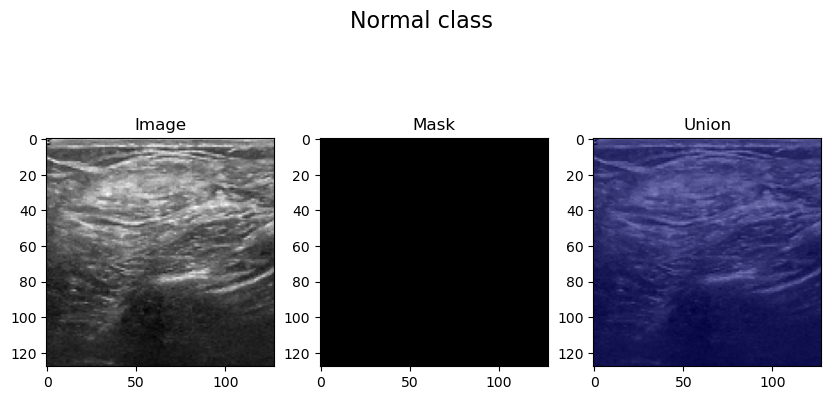

In [6]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

# X[0:437] benign
# X[437:647] malignant
# X[647:780] normal

i = np.random.randint(647,780)
ax[0].imshow(X[i], cmap='gray')
ax[0].set_title('Image')
ax[1].imshow(y[i], cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(X[i], cmap='gray')
ax[2].imshow(tf.squeeze(y[i]), alpha=0.5, cmap='jet')
ax[2].set_title('Union')
fig.suptitle('Normal class', fontsize=16)
plt.show()

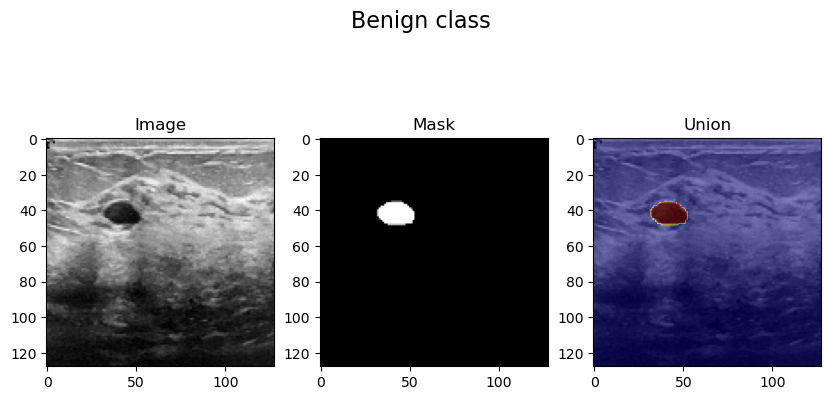

In [7]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

i = np.random.randint(437)
ax[0].imshow(X[i], cmap='gray')
ax[0].set_title('Image')
ax[1].imshow(y[i], cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(X[i], cmap='gray')
ax[2].imshow(tf.squeeze(y[i]), alpha=0.5, cmap='jet')
ax[2].set_title('Union')
fig.suptitle('Benign class', fontsize=16)
plt.show()

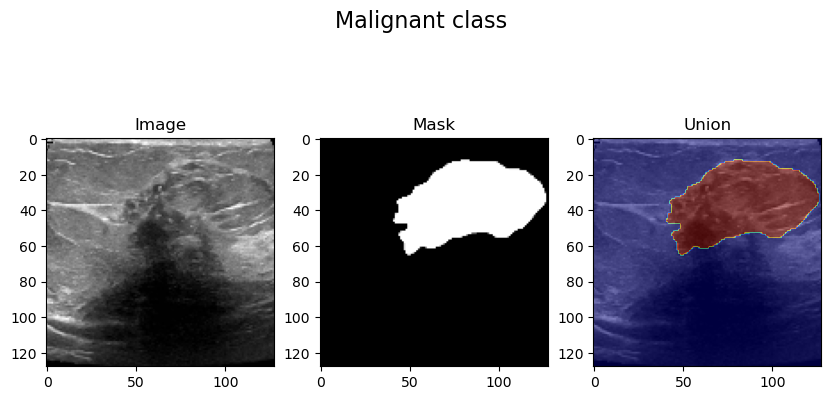

In [8]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

i = np.random.randint(437,647)
ax[0].imshow(X[i], cmap='gray')
ax[0].set_title('Image')
ax[1].imshow(y[i], cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(X[i], cmap='gray')
ax[2].imshow(tf.squeeze(y[i]), alpha=0.5, cmap='jet')
ax[2].set_title('Union')
fig.suptitle('Malignant class', fontsize=16)
plt.show()

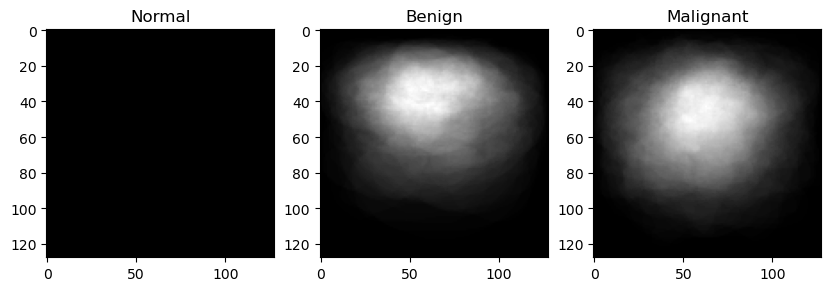

In [9]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

ax[0].imshow(sum(y[647:]), cmap='gray')
ax[0].set_title('Normal')
ax[1].imshow(sum(y[:437]), cmap='gray')
ax[1].set_title('Benign')
ax[2].imshow(sum(y[437:647]), cmap='gray')
ax[2].set_title('Malignant')
plt.show()

In [10]:
# drop normal class because normal class has not mask
X = X[:647]
y = y[:647]

print(f"X shape: {X.shape}     |  y shape: {y.shape}")

# prepare data to modeling
X = np.expand_dims(X, -1)
y = np.expand_dims(y, -1)

print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")

X shape: (647, 128, 128)     |  y shape: (647, 128, 128)

X shape: (647, 128, 128, 1)  |  y shape: (647, 128, 128, 1)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

print(f'\033[92m')
print('X_train shape:',X_train.shape)
print('y_train shape:',y_train.shape)
print('X_test shape:',X_test.shape)
print('y_test shape:',y_test.shape)


X_train shape: (582, 128, 128, 1)
y_train shape: (582, 128, 128, 1)
X_test shape: (65, 128, 128, 1)
y_test shape: (65, 128, 128, 1)


In [12]:
def conv_block(input, num_filters):
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(input)
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(conv)
    return conv

In [13]:
def encoder_block(input, num_filters):
    conv = conv_block(input, num_filters)
    pool = MaxPooling2D((2, 2))(conv)
    return conv, pool

In [14]:
def decoder_block(input, skip_features, num_filters):
    uconv = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    con = concatenate([uconv, skip_features])
    conv = conv_block(con, num_filters)
    return conv

In [15]:
def build_model(input_shape):
    input_layer = Input(input_shape)
    
    s1, p1 = encoder_block(input_layer, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    output_layer = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)
    
    model = Model(input_layer, output_layer, name="U-Net")
    return model

model = build_model(input_shape=(size, size, 1))
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])

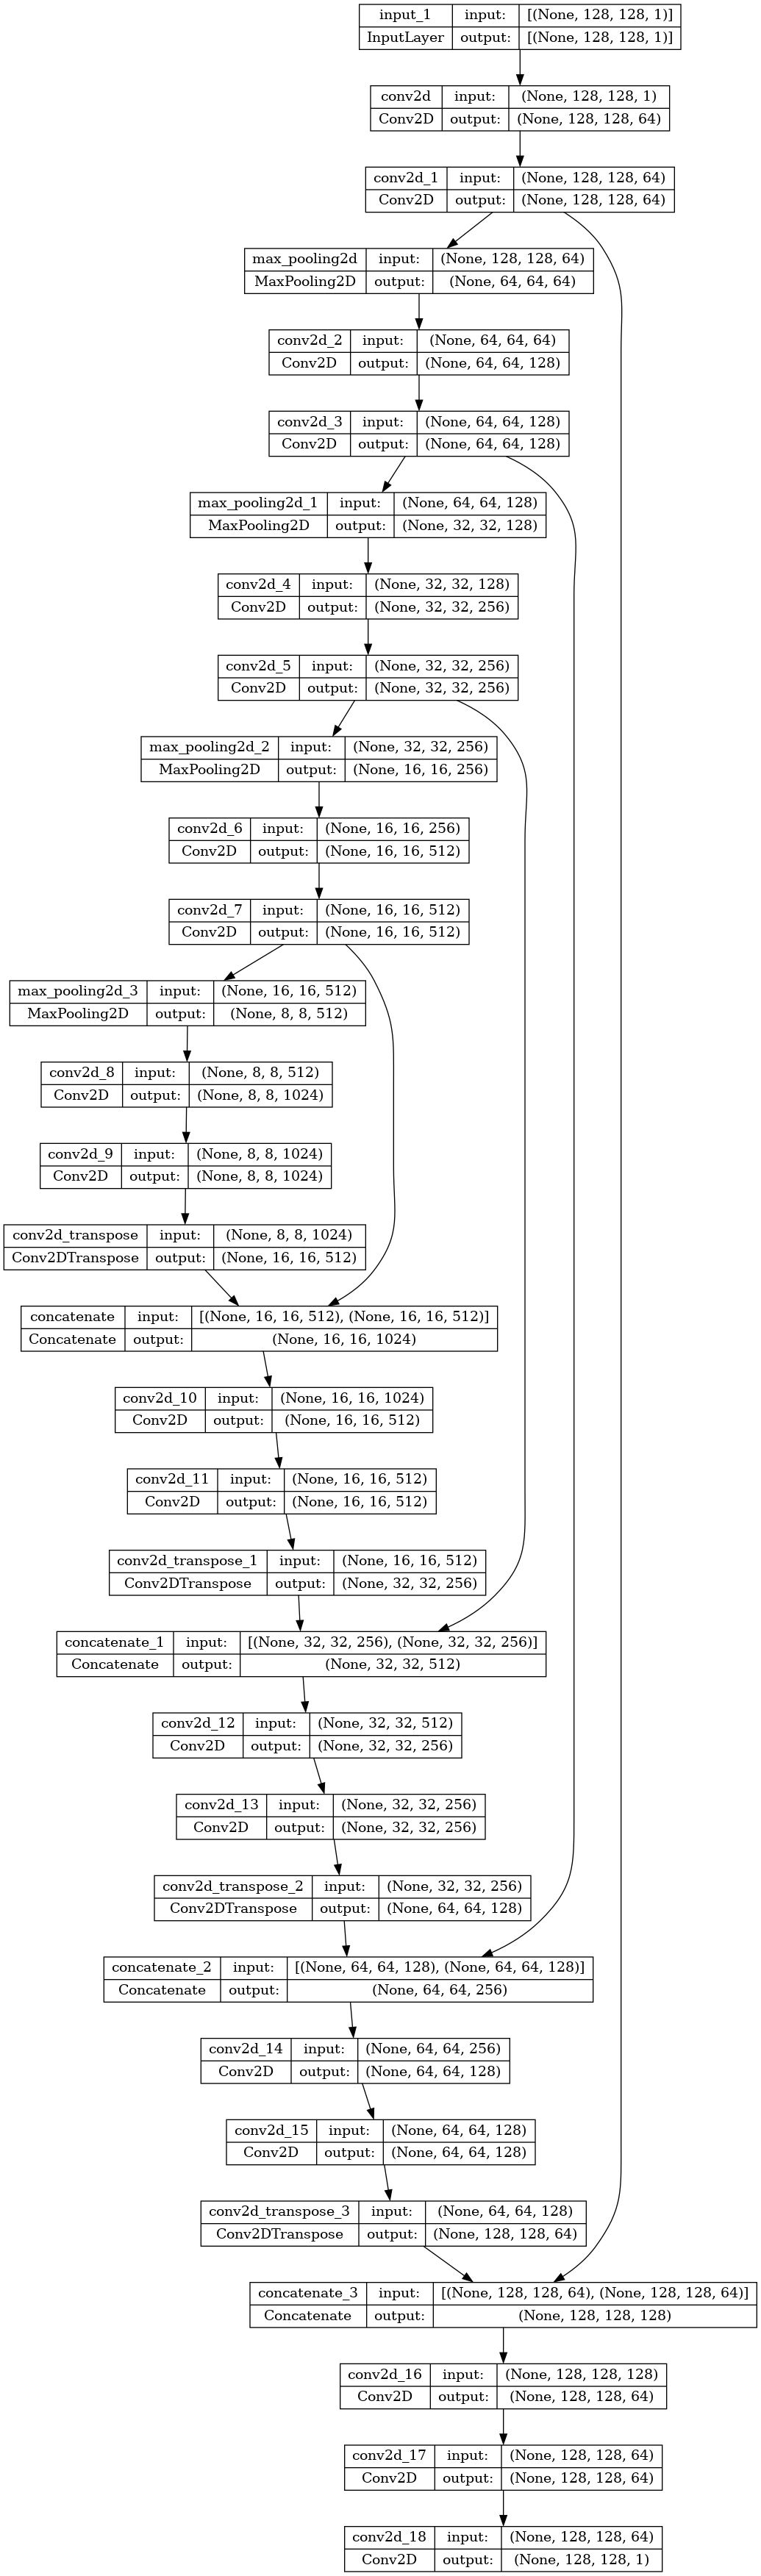

In [16]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [17]:
model.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 64  640         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 128, 128, 64  36928       ['conv2d[0][0]']                 
                                )                                                             

In [18]:
history = model.fit(X_train, y_train, epochs = 100, validation_data = (X_test,y_test))

Epoch 1/100
19/19 [==============================] - 38s 675ms/step - loss: 0.5931 - accuracy: 0.8601 - val_loss: 0.3401 - val_accuracy: 0.8930
Epoch 2/100
19/19 [==============================] - 7s 346ms/step - loss: 0.3383 - accuracy: 0.9056 - val_loss: 0.3315 - val_accuracy: 0.8930
Epoch 3/100
19/19 [==============================] - 7s 348ms/step - loss: 0.3191 - accuracy: 0.9056 - val_loss: 0.3222 - val_accuracy: 0.8930
Epoch 4/100
19/19 [==============================] - 7s 352ms/step - loss: 0.2987 - accuracy: 0.9056 - val_loss: 0.2831 - val_accuracy: 0.8930
Epoch 5/100
19/19 [==============================] - 7s 356ms/step - loss: 0.2462 - accuracy: 0.9060 - val_loss: 0.4703 - val_accuracy: 0.7100
Epoch 6/100
19/19 [==============================] - 7s 361ms/step - loss: 0.2633 - accuracy: 0.8929 - val_loss: 0.2530 - val_accuracy: 0.8930
Epoch 7/100
19/19 [==============================] - 7s 366ms/step - loss: 0.2216 - accuracy: 0.9056 - val_loss: 0.2832 - val_accuracy: 0.893

In [19]:
# ------------------------------------------------------------------
# AUTHOR: Xiaoyang Chen
# ------------------------------------------------------------------
# 将训练好的 31M 参数保存为 HDF5 文件
model.save('unet_breast_31m_dice078.h5')
print("模型权重已成功保存为 unet_breast_31m_dice078.h5！")

模型权重已成功保存为 unet_breast_31m_dice078.h5！


In [20]:
# ------------------------------------------------------------------
# AUTHOR: Xiaoyang Chen
# ------------------------------------------------------------------
import numpy as np
import pandas as pd

# 1. 建立空列表存储每张图的得分
dice_scores = []
iou_scores = []

print("正在对 65 张测试图像进行医学评估...")

for i in range(len(X_test)):
    # 获取预测图 (连续目标：0.0 ~ 1.0)
    pred = model.predict(X_test[i:i+1], verbose=0)[0]
    
    # 【关键步】二值化处理：将连续目标转为二元目标 (0 或 1)
    pred_bin = (pred > 0.5).astype(np.uint8)
    true_bin = (y_test[i] > 0.5).astype(np.uint8) # 确保 y_test 也是 0/1
    
    # 计算 Dice (手动实现，避免库函数类型报错)
    intersection = np.sum(pred_bin * true_bin)
    dice = (2. * intersection) / (np.sum(pred_bin) + np.sum(true_bin) + 1e-7)
    
    dice_scores.append(dice)

# 2. 汇总结果
overall_dice = np.mean(dice_scores)
print(f"\n 评估完成！")
print(f"整个测试集的平均 Dice 系数: {overall_dice:.4f}")

# 3. 找出最难处理的“疑难杂症” (得分最低的 3 张)
worst_indices = np.argsort(dice_scores)[:3]
print(f"得分最低的索引编号: {worst_indices}")

正在对 65 张测试图像进行医学评估...

 评估完成！
整个测试集的平均 Dice 系数: 0.7767
得分最低的索引编号: [52 39 23]


In [21]:
# ------------------------------------------------------------------
# AUTHOR: Xiaoyang Chen
# ------------------------------------------------------------------
import pandas as pd

# 1. 确保你已经运行了之前计算 Dice 的循环
# 建立一个包含 65 条记录的字典列表
test_results = []

print("正在生成 65 张测试图的详细得分表...")

for i in range(len(X_test)):
    # 预测并二值化
    pred = model.predict(X_test[i:i+1], verbose=0)[0]
    pred_bin = (pred > 0.5).astype(np.uint8)
    true_bin = (y_test[i] > 0.5).astype(np.uint8)
    
    # 计算指标
    intersection = np.sum(pred_bin * true_bin)
    dice = (2. * intersection) / (np.sum(pred_bin) + np.sum(true_bin) + 1e-7)
    iou = intersection / (np.sum(pred_bin) + np.sum(true_bin) - intersection + 1e-7)
    
    # 记录数据
    test_results.append({
        'Test_Index': i,
        'Dice_Score': round(dice, 4),
        'IoU_Score': round(iou, 4),
        'Case_Type': 'Malignant' if i in [9, 10, 28] else 'Other' # 这里你可以根据之前的分类逻辑细化
    })

# 2. 转换为 DataFrame
df_metrics = pd.DataFrame(test_results)

# 3. 保存为 CSV 文件
df_metrics.to_csv('Breast_Ultrasound_Test_Metrics.csv', index=False)

print("表格已生成！请在 Kaggle 右侧面板的 'Output' 文件夹中下载 Breast_Ultrasound_Test_Metrics.csv")

# 顺便打印前 10 行给你预览
print(df_metrics.head(10))

正在生成 65 张测试图的详细得分表...
表格已生成！请在 Kaggle 右侧面板的 'Output' 文件夹中下载 Breast_Ultrasound_Test_Metrics.csv
   Test_Index  Dice_Score  IoU_Score  Case_Type
0           0      0.8400     0.7242      Other
1           1      0.7931     0.6571      Other
2           2      0.9149     0.8431      Other
3           3      0.7963     0.6615      Other
4           4      0.7868     0.6485      Other
5           5      0.8516     0.7415      Other
6           6      0.9197     0.8513      Other
7           7      0.8184     0.6926      Other
8           8      0.9274     0.8646      Other
9           9      0.6065     0.4353  Malignant


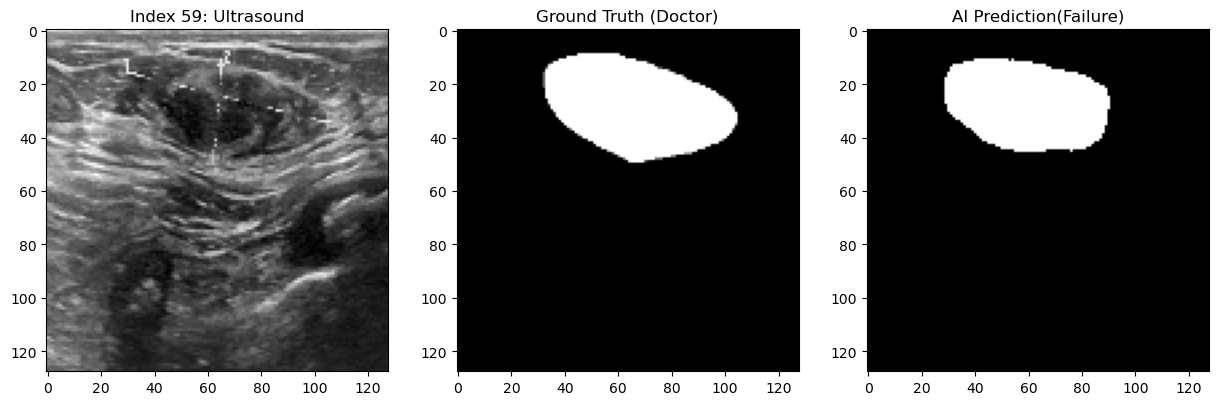

--- 索引 59 会诊结束 ---


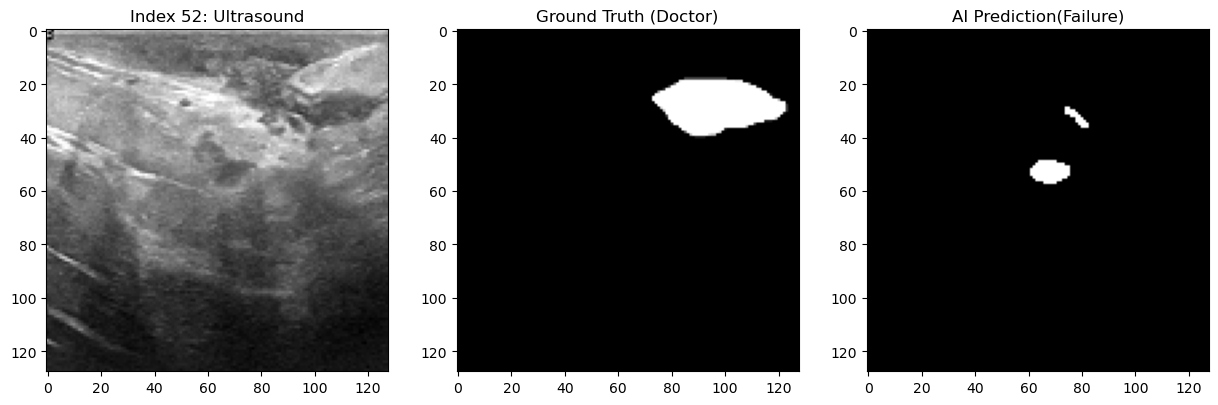

--- 索引 52 会诊结束 ---


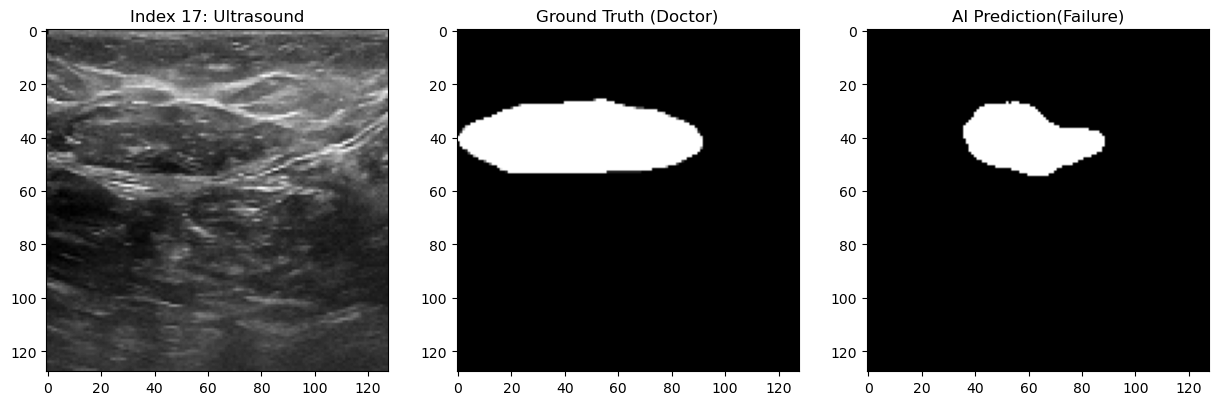

--- 索引 17 会诊结束 ---


In [22]:
# ------------------------------------------------------------------
# AUTHOR: Xiaoyang Chen
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

# 重点会诊 [59,52,17]
worst_indices = [59,52,17]

for idx in worst_indices:
    plt.figure(figsize=(15, 5))
    
    # 原始超声图
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"Index {idx}: Ultrasound")
    
    # 医生金标准 (GT)
    plt.subplot(1, 3, 2)
    plt.imshow(y_test[idx], cmap='gray')
    plt.title("Ground Truth (Doctor)")
    
    # AI 预测结果
    plt.subplot(1, 3, 3)
    # 获取预测概率图并转为二值图
    pred = model.predict(X_test[idx:idx+1], verbose=0)[0]
    pred_bin = (pred > 0.5).astype(np.uint8)
    plt.imshow(pred_bin, cmap='gray')
    plt.title("AI Prediction(Failure)")

    plt.savefig(f'Failure_Case_Idex_{idx}.png',bbox_inches='tight',dpi=150)
    
    plt.show()
    print(f"--- 索引 {idx} 会诊结束 ---")

正在生成 Dice 分数分布直方图...


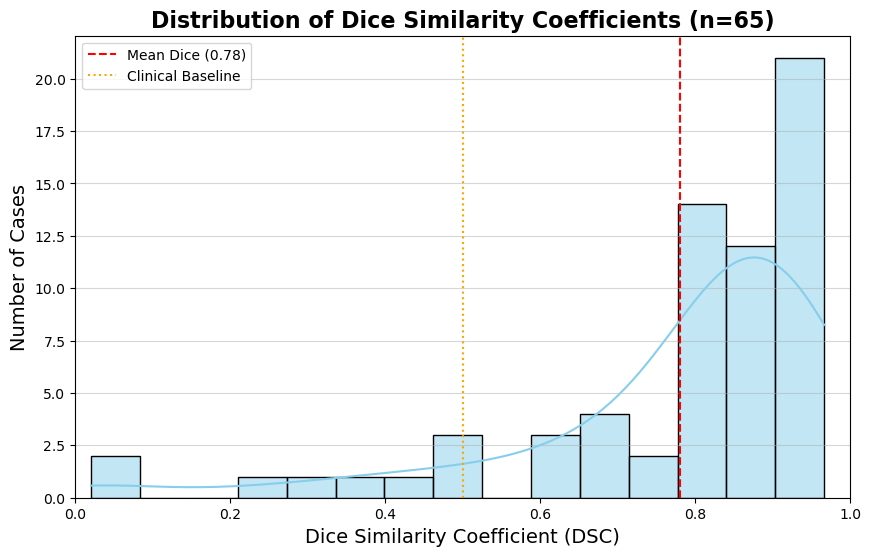

图片已成功生成在 Output 文件夹中：Dice_Distribution_Plot.png


In [23]:
# ------------------------------------------------------------------
# AUTHOR: Xiaoyang Chen
# ------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 确保你已经加载了包含 65 张测试图 Dice 分数的 DataFrame
# 如果你之前的变量名不一样，请替换 df_metrics
# 假设你的 DataFrame 叫 df_metrics，且有 'Dice_Score' 这列

print("正在生成 Dice 分数分布直方图...")

plt.figure(figsize=(10, 6))

# 使用 Seaborn 画直方图 + 密度曲线 (KDE)
# 它可以清晰地显示大多数 Dice 分数集中在 0.8-0.9 之间
sns.histplot(df_metrics['Dice_Score'], bins=15, kde=True, color='skyblue', edgecolor='black', linewidth=1)

# 添加医学 AI 的标准参考线
plt.axvline(x=0.78, color='red', linestyle='--', label='Mean Dice (0.78)') # 平均分参考线
plt.axvline(x=0.5, color='orange', linestyle=':', label='Clinical Baseline') # 临床及格线

# 添加图表信息
plt.title("Distribution of Dice Similarity Coefficients (n=65)", fontsize=16, fontweight='bold')
plt.xlabel("Dice Similarity Coefficient (DSC)", fontsize=14)
plt.ylabel("Number of Cases", fontsize=14)
plt.xlim(0, 1.0) # Dice 范围在 0-1 之间
plt.legend()
plt.grid(axis='y', alpha=0.5)

# 【核心步】：先保存，再显示
save_path = '/kaggle/working/Dice_Distribution_Plot.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"图片已成功生成在 Output 文件夹中：Dice_Distribution_Plot.png")

找到成功案例索引：[53 60 13]
正在生成成功案例对比图...


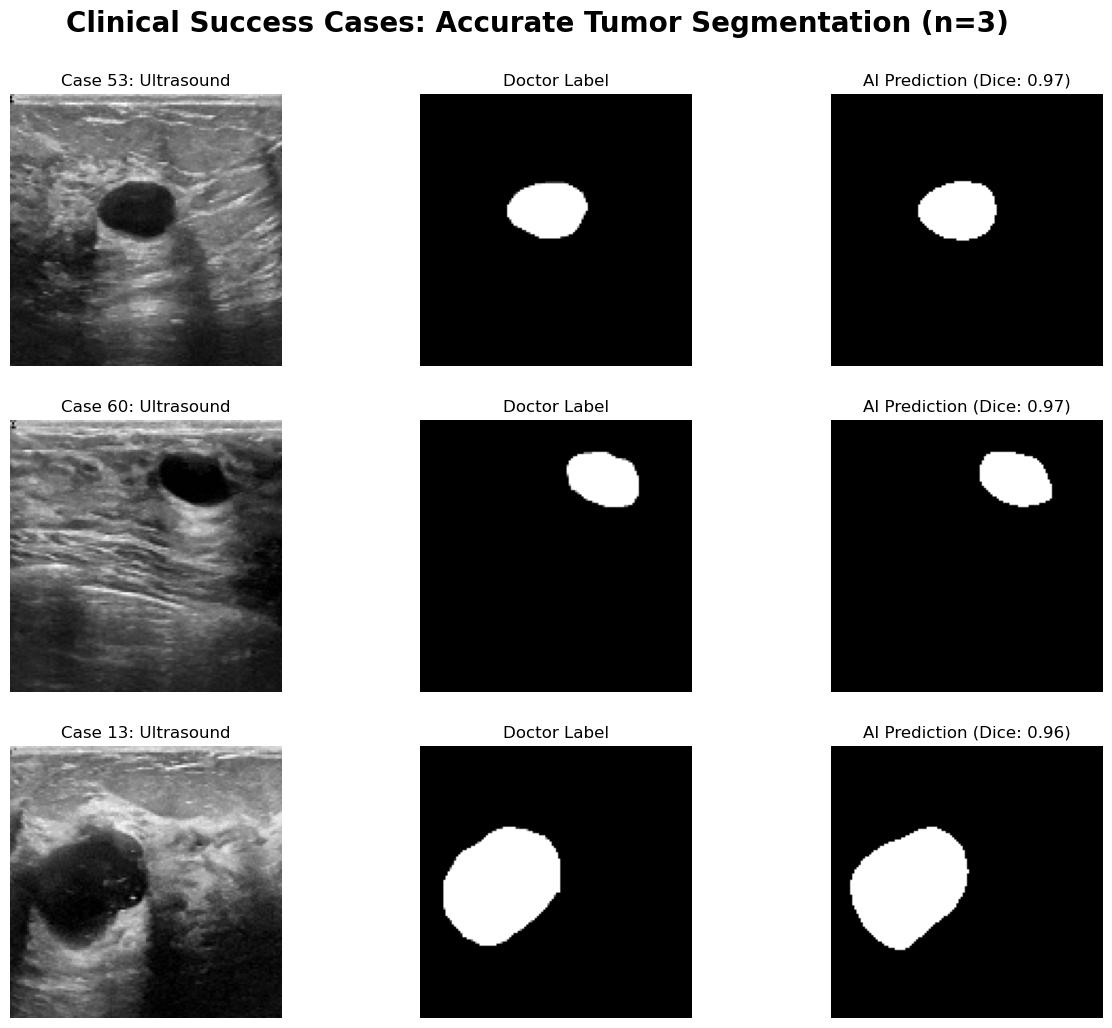

图片已成功生成在 Output 文件夹中：Success_Cases.png


In [24]:
# ------------------------------------------------------------------
# AUTHOR: Xiaoyang Chen
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import FileLink

# 1. 选择 3 个得分最高的病例作为成功案例
# 我们通过 argsort 找出 Dice 分数最高的前 3 名
all_dice = []
for i in range(len(X_test)):
    # 预测并二值化
    pred = model.predict(X_test[i:i+1], verbose=0)[0]
    pred_bin = (pred > 0.5).astype(np.uint8)
    true_bin = (y_test[i] > 0.5).astype(np.uint8)
    
    # 计算指标
    intersection = np.sum(pred_bin * true_bin)
    dice = (2. * intersection) / (np.sum(pred_bin) + np.sum(true_bin) + 1e-7)
    all_dice.append(dice)

# 找出 Dice 分数最高的前 3 名索引
best_indices = np.argsort(all_dice)[-3:] # 取最后三个最大值

print(f"找到成功案例索引：{best_indices[::-1]}")
print("正在生成成功案例对比图...")

# 2. 开始绘图
plt.figure(figsize=(15, 12)) # 调大一点，放下 3 行图片

row_num = 0
for idx in best_indices[::-1]: # 按分数从高到低显示
    # 获取数据
    orig_img = X_test[idx]
    gt_mask = y_test[idx]
    pred = model.predict(X_test[idx:idx+1], verbose=0)[0]
    pred_bin = (pred > 0.5).astype(np.uint8)
    
    # 获取当前得分
    dice_val = all_dice[idx]
    
    # 第一列：原始超声图
    plt.subplot(3, 3, row_num*3 + 1)
    plt.imshow(orig_img, cmap='gray')
    plt.title(f"Case {idx}: Ultrasound")
    plt.axis('off')
    
    # 第二列：医生标注 (Ground Truth)
    plt.subplot(3, 3, row_num*3 + 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title("Doctor Label")
    plt.axis('off')
    
    # 第三列：AI 预测 (Dice Score)
    plt.subplot(3, 3, row_num*3 + 3)
    plt.imshow(pred_bin, cmap='gray')
    plt.title(f"AI Prediction (Dice: {dice_val:.2f})")
    plt.axis('off')
    
    row_num += 1

# 添加主标题
plt.suptitle("Clinical Success Cases: Accurate Tumor Segmentation (n=3)", fontsize=20, fontweight='bold', y=0.95)

# 【核心步】：保存成功图
save_path_success = '/kaggle/working/Success_Cases.png'
plt.savefig(save_path_success, bbox_inches='tight', dpi=150)
plt.show()

print(f"图片已成功生成在 Output 文件夹中：Success_Cases.png")

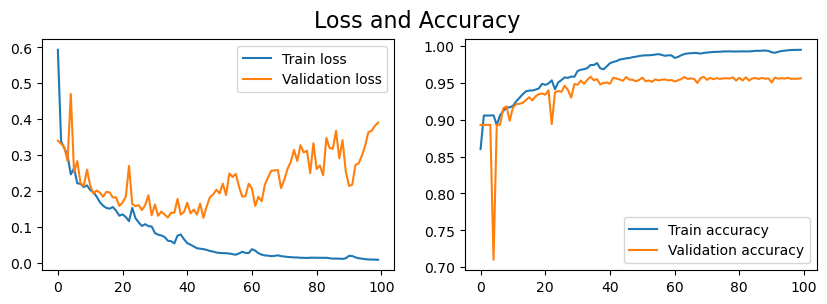

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10,3))
ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
ax[0].legend()
ax[1].plot(history.epoch, history.history["accuracy"], label="Train accuracy")
ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation accuracy")
ax[1].legend()
fig.suptitle('Loss and Accuracy', fontsize=16)
plt.show()

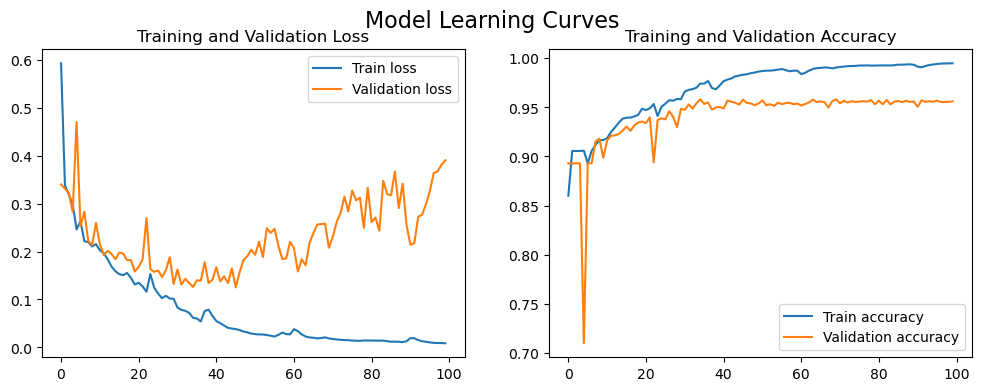

学习曲线已保存为 Training_Learning_Curves.png


In [26]:
# ------------------------------------------------------------------
# AUTHOR: Xiaoyang Chen
# ------------------------------------------------------------------
# 1. 重新绘制并保存（确保顺序：先 savefig，后 show）
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 左图：Loss
ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
ax[0].set_title('Training and Validation Loss')
ax[0].legend()

# 右图：Accuracy
ax[1].plot(history.epoch, history.history["accuracy"], label="Train accuracy")
ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation accuracy")
ax[1].set_title('Training and Validation Accuracy')
ax[1].legend()

plt.suptitle('Model Learning Curves', fontsize=16)

# 【核心保存代码】
plt.savefig('Training_Learning_Curves.png', bbox_inches='tight', dpi=150)
plt.show()

print("学习曲线已保存为 Training_Learning_Curves.png")

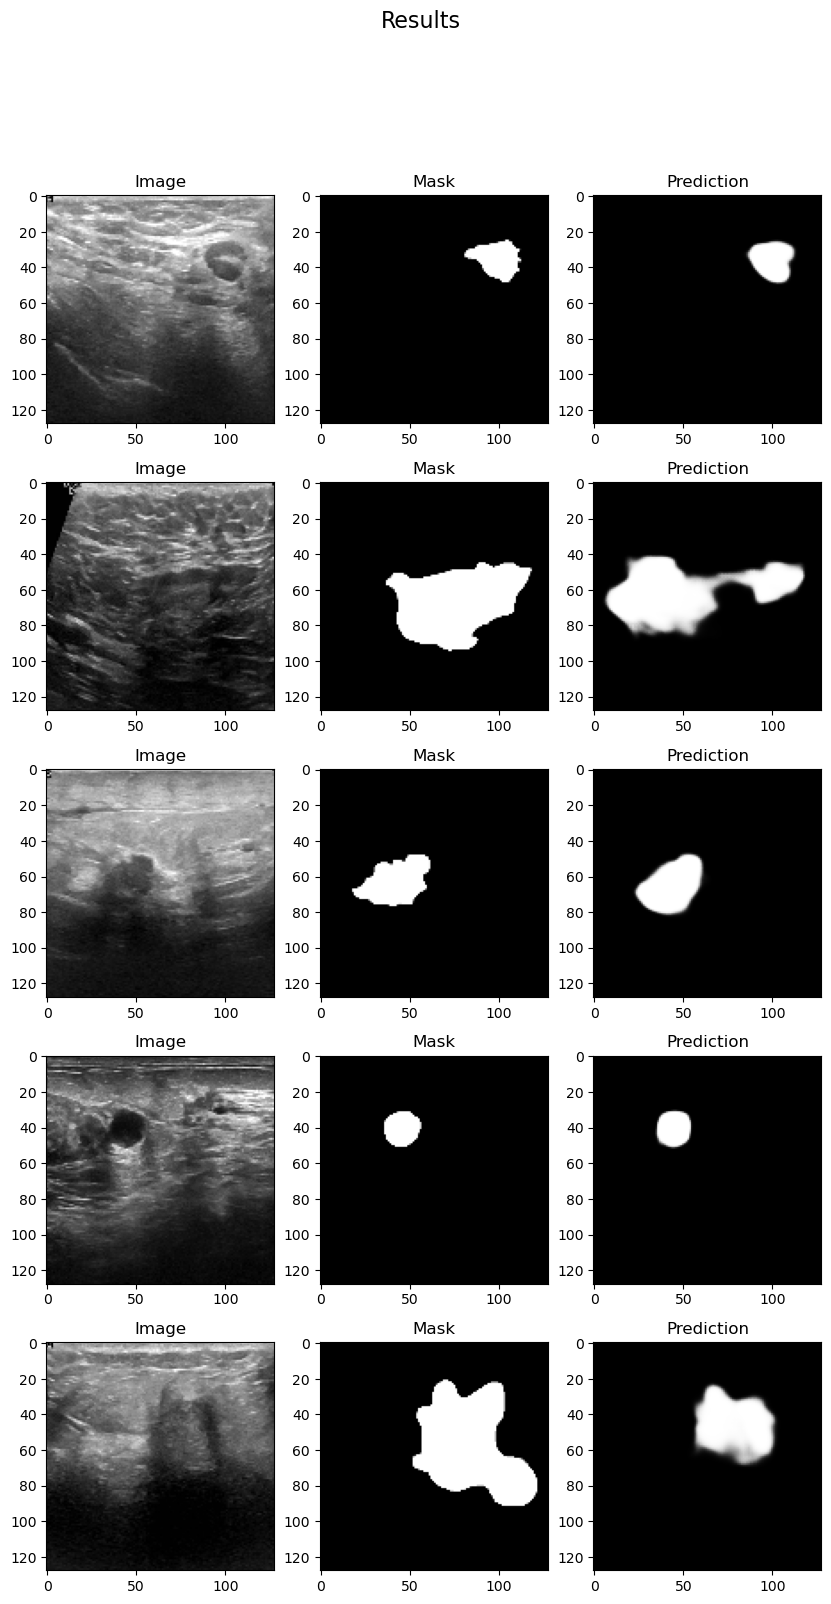

In [27]:
fig, ax = plt.subplots(5,3, figsize=(10,18))

j = np.random.randint(0, X_test.shape[0], 5)
for i in range(5):
    ax[i,0].imshow(X_test[j[i]], cmap='gray')
    ax[i,0].set_title('Image')
    ax[i,1].imshow(y_test[j[i]], cmap='gray')
    ax[i,1].set_title('Mask')
    ax[i,2].imshow(model.predict(np.expand_dims(X_test[j[i]],0),verbose=0)[0], cmap='gray')
    ax[i,2].set_title('Prediction')
fig.suptitle('Results', fontsize=16)
plt.show()

In [28]:
print(f'\033[93m')
y_pred=model.predict(X_test,verbose=0)
y_pred_thresholded = y_pred > 0.5

# mean Intersection-Over-Union metric
IOU_keras = MeanIoU(num_classes=2)
IOU_keras.update_state(y_pred_thresholded, y_test)
print("Mean IoU =", IOU_keras.result().numpy())

prec_score = Precision()
prec_score.update_state(y_pred_thresholded, y_test)
p = prec_score.result().numpy()
print('Precision Score = %.3f' % p)

recall_score = Recall()
recall_score.update_state(y_pred_thresholded, y_test)
r = recall_score.result().numpy()
print('Recall Score = %.3f' % r)

f1_score = 2*(p*r)/(p+r)
print('F1 Score = %.3f' % f1_score)


Mean IoU = 0.8006698
Precision Score = 0.733
Recall Score = 0.845
F1 Score = 0.785
